<a href="https://colab.research.google.com/github/Erinda27/Data-and-Decision-making-/blob/main/Unit_5_HR_CSV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving  Unit 05 - Human Resources (1).csv to  Unit 05 - Human Resources (1) (2).csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(' Unit 05 - Human Resources (1) (2).csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

Shape: (22211, 34)

Columns: ['Age (bin)', 'Age (bin)1', 'Birthdate', 'Complete Name', 'Department', 'Employement Status', 'First Name', 'Gender', 'Hire Date', 'Id', 'Jobtitle', 'Last Name', 'Location', 'Location City', 'Location State', 'Race', 'Selected Location', 'Selected Year', 'Status', 'Tenure', 'Termdate', 'Termdate (group)', 'Y/Q selection (two step) selected and prior year', '% change hiring number', '% terminated', 'Age', 'change hiring number', 'current year hiring number', 'hiring down', 'hiring up', 'HR', 'min(-1.0)', 'min(1.0)', 'prior year hiring number']


,Age (bin),Age (bin)1,Birthdate,Complete Name,Department,Employement Status,First Name,Gender,Hire Date,Id,...,% terminated,Age,change hiring number,current year hiring number,hiring down,hiring up,HR,min(-1.0),min(1.0),prior year hiring number
0,30-34,30-35,06/04/1991 00:00,Kimmy Walczynski,Engineering,Active,Kimmy,Male,20/01/2002 00:00,00-0037846,...,0,33,NaN,NaN,NaN,NaN,1,-1,1,NaN
1,40-44,40-45,29/06/1984 00:00,Ignatius Springett,Business Development,Active,Ignatius,Male,04/08/2019 00:00,00-0041533,...,0,40,NaN,NaN,NaN,NaN,1,-1,1,NaN
2,35-39,35-40,29/07/1989 00:00,Corbie Bittlestone,Sales,Active,Corbie,Male,10/12/2010 00:00,00-0045747,...,0,35,NaN,NaN,NaN,NaN,1,-1,1,NaN
3,40-44,40-45,14/09/1982 00:00,Baxy Matton,Services,Active,Baxy,Female,04/10/2005 00:00,00-0055274,...,0,42,NaN,NaN,NaN,NaN,1,-1,1,NaN
4,30-34,30-35,04/11/1994 00:00,Terrell Suff,Product Management,Active,Terrell,Female,29/09/2010 00:00,00-0076100,...,0,30,NaN,NaN,NaN,NaN,1,-1,1,NaN


In [ ]:
df['StatusFlag'] = df['Termdate'].notna().map({False: 'Active', True: 'Terminated'})

print(df['StatusFlag'].value_counts())

StatusFlag
Active        18282
Terminated     3929
Name: count, dtype: int64


StatusFlag      Active  Terminated  Total  TerminationRate_%
Gender                                                      
Female            8454        1866  10320          18.081395
Male              9326        1960  11286          17.366649
Non-Conforming     502         103    605          17.024793


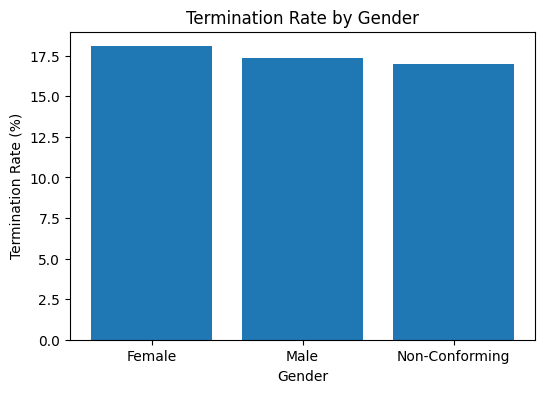

In [ ]:
gender_counts = df.groupby(['Gender', 'StatusFlag']).size().unstack(fill_value=0)
gender_counts['Total'] = gender_counts.sum(axis=1)
gender_counts['TerminationRate_%'] = (gender_counts.get('Terminated', 0) / gender_counts['Total']) * 100

print(gender_counts)

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts['TerminationRate_%'])
plt.title('Termination Rate by Gender')
plt.ylabel('Termination Rate (%)')
plt.xlabel('Gender')
plt.show()

StatusFlag                                 Active  Terminated  Total  \
Race                                                                   
American Indian or Alaska Native             1098         229   1327   
Asian                                        2936         626   3562   
Black or African American                    2982         636   3618   
Hispanic or Latino                           2074         427   2501   
Native Hawaiian or Other Pacific Islander     991         238   1229   
Two or More Races                            2989         659   3648   
White                                        5212        1114   6326   

StatusFlag                                 TerminationRate_%  
Race                                                          
American Indian or Alaska Native                   17.256971  
Asian                                              17.574396  
Black or African American                          17.578773  
Hispanic or Latino                  

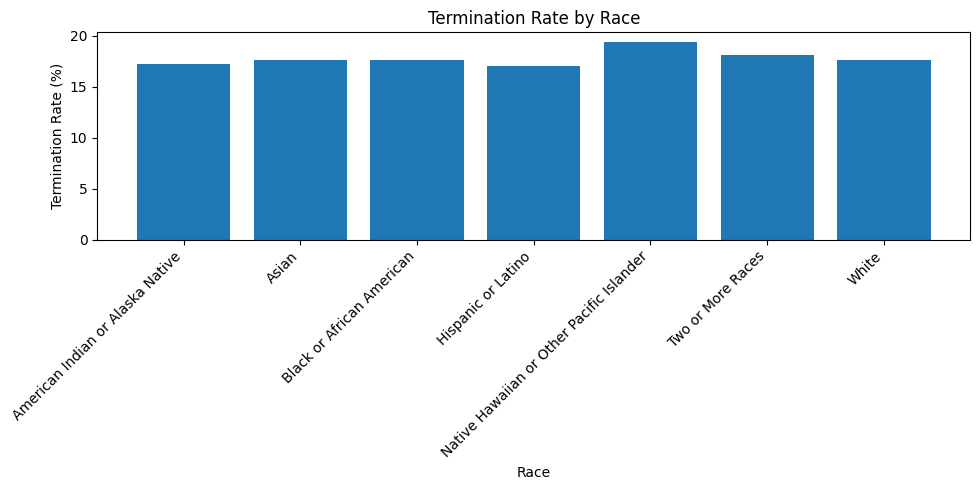

In [ ]:
race_counts = df.groupby(['Race', 'StatusFlag']).size().unstack(fill_value=0)
race_counts['Total'] = race_counts.sum(axis=1)
race_counts['TerminationRate_%'] = (race_counts.get('Terminated', 0) / race_counts['Total']) * 100

print(race_counts)

plt.figure(figsize=(10,5))
plt.bar(race_counts.index, race_counts['TerminationRate_%'])
plt.title('Termination Rate by Race')
plt.ylabel('Termination Rate (%)')
plt.xlabel('Race')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

StatusFlag                Active  Terminated  Total  TerminationRate_%
Department                                                            
Auditing                      40          12     52          23.076923
Legal                        248          63    311          20.257235
Research and Development     872         212   1084          19.557196
Support                      772         182    954          19.077568
Sales                       1497         335   1832          18.286026
Product Management           527         114    641          17.784711
Engineering                 5501        1185   6686          17.723602
Accounting                  2747         586   3333          17.581758
Services                    1392         293   1685          17.388724
Training                    1400         291   1691          17.208752
Human Resources             1498         309   1807          17.100166
Business Development        1366         275   1641          16.758074
Market

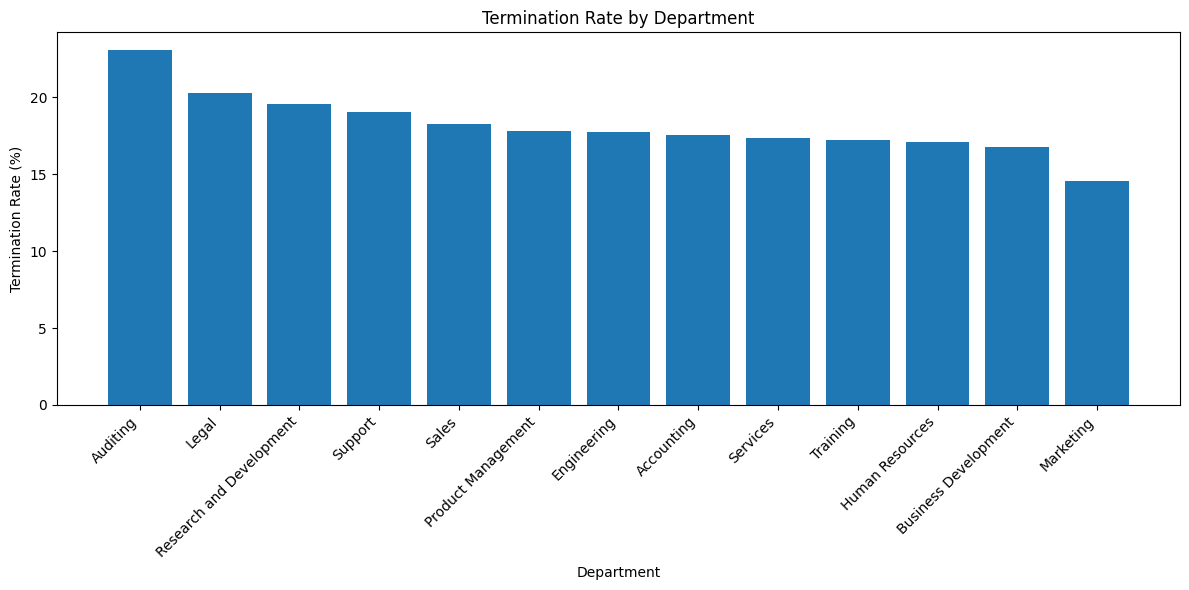

In [ ]:
dept_counts = df.groupby(['Department', 'StatusFlag']).size().unstack(fill_value=0)
dept_counts['Total'] = dept_counts.sum(axis=1)
dept_counts['TerminationRate_%'] = (dept_counts.get('Terminated', 0) / dept_counts['Total']) * 100

sorted_dept = dept_counts.sort_values('TerminationRate_%', ascending=False)
print(sorted_dept)

plt.figure(figsize=(12,6))
plt.bar(sorted_dept.index, sorted_dept['TerminationRate_%'])
plt.title('Termination Rate by Department')
plt.ylabel('Termination Rate (%)')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_employees = len(df)
terminated_employees = (df['StatusFlag'] == 'Terminated').sum()
overall_turnover = (terminated_employees / total_employees) * 100

print('Total employees:', total_employees)
print('Terminated employees:', terminated_employees)
print('Overall turnover (%):', round(overall_turnover, 2))

Total employees: 22211
Terminated employees: 3929
Overall turnover (%): 17.69
